<a href="https://colab.research.google.com/github/logansivam/Testing/blob/main/DMDW_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Display settings
pd.set_option('display.max_columns', None)


In [12]:
df = pd.read_csv("train.csv")


In [13]:
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [14]:
df.shape


(45593, 20)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [16]:
df.describe()


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [17]:
df.isnull().sum()


,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0


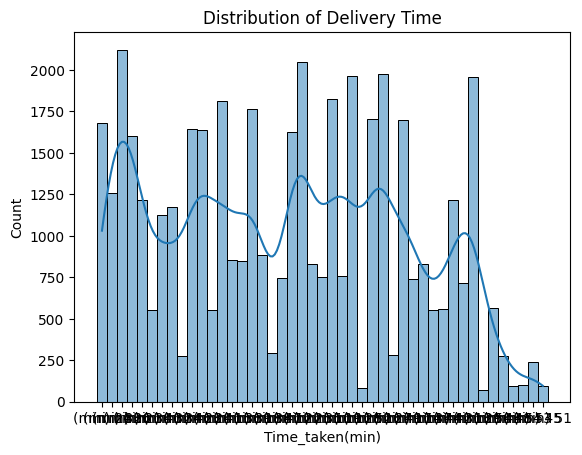

In [18]:
plt.figure()
sns.histplot(df['Time_taken(min)'], kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

In [19]:
df.columns = df.columns.str.strip()


In [20]:
df.drop(['ID', 'Delivery_person_ID'], axis=1, inplace=True)


In [21]:
df.fillna(method='ffill', inplace=True)


/tmp/ipython-input-4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [22]:
categorical_cols = df.select_dtypes(include='object').columns

encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [23]:
scaler = StandardScaler()
numerical_cols = df.drop('Time_taken(min)', axis=1).columns

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [24]:
# Simulated fact table (conceptual)
fact_delivery = df[['Time_taken(min)']]

# Simulated dimension tables
dim_location = df[['Restaurant_latitude', 'Restaurant_longitude']]
dim_time = df[['Order_Date']]
dim_rider = df[['Delivery_person_Age', 'Delivery_person_Ratings']]


In [25]:
X = df.drop('Time_taken(min)', axis=1)
y = df['Time_taken(min)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [27]:
y_pred = model.predict(X_test)


In [28]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 3.6692554008114926
RMSE: 4.686767318035894
R2 Score: 0.7494724601487284


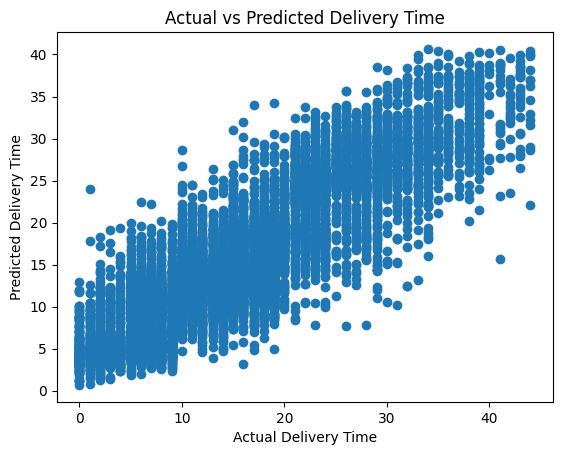

In [29]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()


In [30]:
df.to_csv("cleaned_food_delivery_data.csv", index=False)


**NEWLY UPDATED**

In [31]:
# Predict delivery time
y_pred = model.predict(X_test)


In [33]:
# Create results DataFrame
results = X_test.copy()
results['Actual_Delivery_Time'] = y_test.values
results['Predicted_Delivery_Time'] = y_pred

In [34]:
# Estimate jobs per day (OUT-OF-THE-BOX LOGIC)
WORKING_MINUTES_PER_DAY = 480  # 8 hours per day

In [35]:
results['Estimated_Jobs_Per_Day'] = (
    WORKING_MINUTES_PER_DAY / results['Predicted_Delivery_Time']
).round(0)

In [36]:
# View results
results[['Predicted_Delivery_Time', 'Estimated_Jobs_Per_Day']].head()

,Predicted_Delivery_Time,Estimated_Jobs_Per_Day
7725,33.27,14.0
949,36.35,13.0
44893,26.71,18.0
42071,32.50,15.0
27091,25.32,19.0


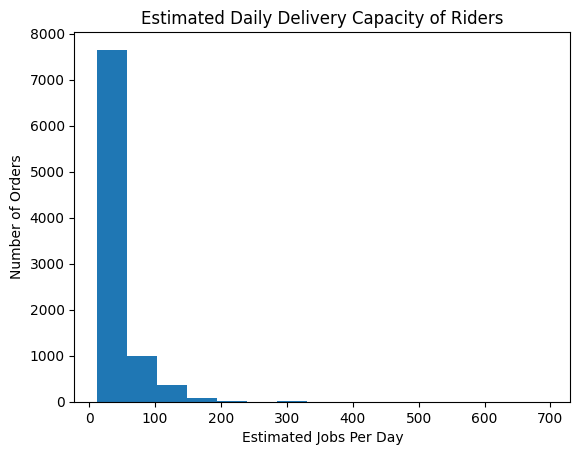

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(results['Estimated_Jobs_Per_Day'], bins=15)
plt.xlabel("Estimated Jobs Per Day")
plt.ylabel("Number of Orders")
plt.title("Estimated Daily Delivery Capacity of Riders")
plt.show()
